Running single training curve (N=10, r=3.0, no punishment)...


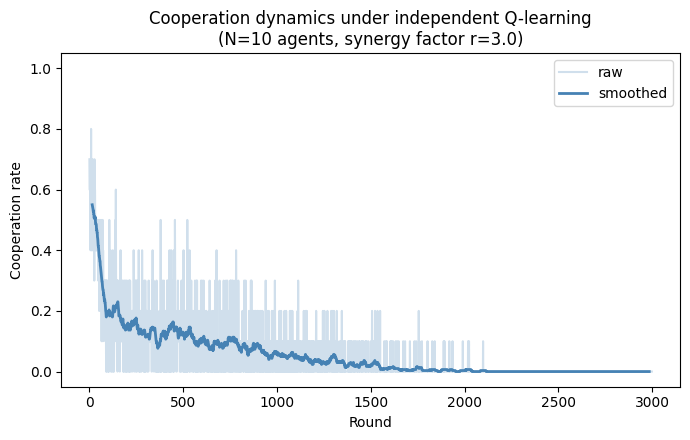

Saved training_curve.png
Running synergy-factor sweep (no punishment)...


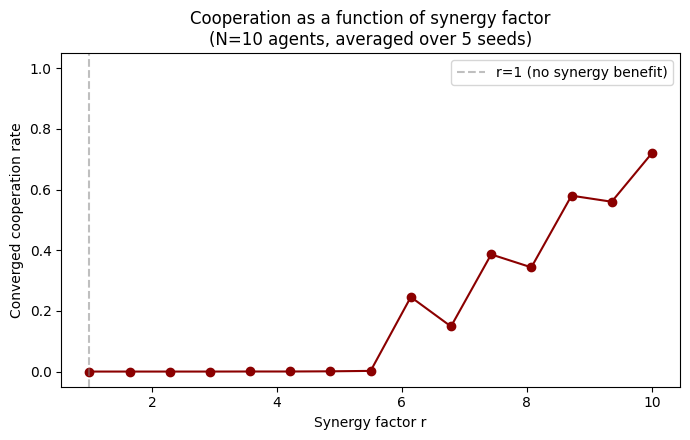

Saved phase_diagram.png
Running punishment-strength sweep (the main result)...


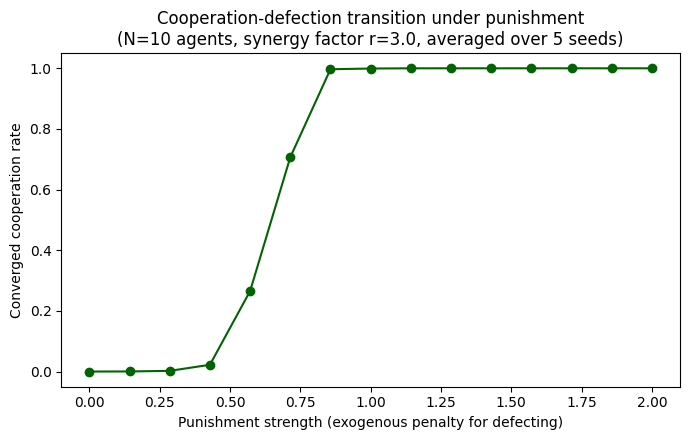

Saved punishment_phase_diagram.png
Done.


In [1]:
"""
Toy Multi-Agent Reinforcement Learning Simulation
==================================================

Iterated N-Player Public Goods Game with independent Q-learning agents.

A small, exploratory attempt to connect statistical-mechanics style
cooperation/defection models (Ising-type Hamiltonians with punishment
terms) with MARL, where cooperation is learned via reward feedback
rather than imposed by a Hamiltonian.

Agents choose to CONTRIBUTE (cooperate) or FREE-RIDE (defect); an
exogenous PUNISHMENT term penalizes defectors (a simple stand-in for
an external enforcement/arbiter mechanism). Sweeping punishment
strength shows a phase-like transition from mostly defection to
mostly cooperation, loosely reminiscent of the punishment thresholds
in the Ising-DM cooperation/defection work -- though this is a much
simpler, stateless setup and the analogy shouldn't be overstated.

Toy model: independent tabular Q-learning, no opponent modelling or
communication.
"""

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field


# ----------------------------------------------------------------------
# Environment: N-player Public Goods Game
# ----------------------------------------------------------------------

class PublicGoodsGame:
    """
    N agents each choose an action in {0, 1}: 0 = free-ride (defect),
    1 = contribute (cooperate). Contributions are pooled, multiplied by
    synergy factor r, and split equally among all agents.

    payoff_i = endowment - c*a_i + (r*c*sum(a))/N

    For 1 < r < N: mutual cooperation is Pareto-optimal, but defection
    is individually dominant -- a genuine social dilemma.
    """

    def __init__(self, n_agents: int, synergy_factor: float,
                 endowment: float = 1.0, cost: float = 1.0,
                 punishment_strength: float = 0.0):
        self.n = n_agents
        self.r = synergy_factor
        self.endowment = endowment
        self.c = cost
        self.p = punishment_strength  # exogenous penalty for defecting

    def step(self, actions: np.ndarray) -> np.ndarray:
        """
        Returns payoffs for actions (shape (n,), values in {0,1}).
        Defectors incur an extra penalty `self.p` (exogenous
        enforcement, not peer-to-peer costly punishment).
        """
        total_contribution = self.c * actions.sum()
        share = (self.r * total_contribution) / self.n
        payoffs = self.endowment - self.c * actions + share
        payoffs -= self.p * (1 - actions)  # penalty applied to defectors
        return payoffs


# ----------------------------------------------------------------------
# Agent: independent tabular Q-learning
# ----------------------------------------------------------------------

@dataclass
class QLearningAgent:
    """
    Independent Q-learning agent, stateless, 2 actions {0: defect,
    1: cooperate}. Softmax exploration with temperature `tau`,
    analogous to a two-level Boltzmann distribution.
    """

    alpha: float = 0.1      # learning rate
    tau: float = 0.5        # exploration temperature
    q: np.ndarray = field(default_factory=lambda: np.zeros(2))

    def act(self, rng: np.random.Generator) -> int:
        # softmax over Q-values with temperature tau
        logits = self.q / max(self.tau, 1e-6)
        logits -= logits.max()  # numerical stability
        probs = np.exp(logits)
        probs /= probs.sum()
        return int(rng.choice([0, 1], p=probs))

    def update(self, action: int, reward: float):
        # stateless Q-learning update (no next-state bootstrapping needed
        # since the game is a repeated stage game with no state transitions)
        self.q[action] += self.alpha * (reward - self.q[action])


# ----------------------------------------------------------------------
# Simulation driver
# ----------------------------------------------------------------------

def run_simulation(n_agents: int, synergy_factor: float, n_rounds: int,
                    tau: float = 0.5, alpha: float = 0.1,
                    anneal: bool = True, seed: int = 0,
                    punishment_strength: float = 0.0) -> np.ndarray:
    """
    Returns cooperation rate per round, shape (n_rounds,).
    If anneal=True, tau decays toward a floor over training.
    """
    rng = np.random.default_rng(seed)
    env = PublicGoodsGame(n_agents, synergy_factor,
                           punishment_strength=punishment_strength)
    agents = [QLearningAgent(alpha=alpha, tau=tau) for _ in range(n_agents)]

    coop_rate = np.zeros(n_rounds)
    tau_floor = 0.05
    decay = (tau_floor / tau) ** (1.0 / n_rounds) if anneal else 1.0

    for t in range(n_rounds):
        actions = np.array([agent.act(rng) for agent in agents])
        payoffs = env.step(actions)
        for agent, a, r in zip(agents, actions, payoffs):
            agent.update(a, r)
            if anneal:
                agent.tau = max(agent.tau * decay, tau_floor)
        coop_rate[t] = actions.mean()

    return coop_rate


def sweep_synergy_factor(n_agents: int, r_values: np.ndarray, n_rounds: int,
                          n_seeds: int = 5, tau: float = 0.5,
                          alpha: float = 0.1,
                          punishment_strength: float = 0.0) -> np.ndarray:
    """
    Mean converged cooperation rate (final 10% of rounds, averaged
    over seeds) as a function of synergy factor r -- an order
    parameter curve.
    """
    tail = max(1, n_rounds // 10)
    results = np.zeros(len(r_values))

    for i, r in enumerate(r_values):
        final_rates = []
        for s in range(n_seeds):
            coop_rate = run_simulation(n_agents, r, n_rounds, tau=tau,
                                        alpha=alpha, seed=s * 1000 + i,
                                        punishment_strength=punishment_strength)
            final_rates.append(coop_rate[-tail:].mean())
        results[i] = np.mean(final_rates)

    return results


def sweep_punishment_strength(n_agents: int, synergy_factor: float,
                               p_values: np.ndarray, n_rounds: int,
                               n_seeds: int = 5, tau: float = 0.5,
                               alpha: float = 0.1) -> np.ndarray:
    """
    Fixes synergy factor r (dilemma range) and sweeps punishment
    strength p. Returns converged cooperation rate vs. p -- may show
    a phase-like shift from mostly defection to mostly cooperation.
    """
    tail = max(1, n_rounds // 10)
    results = np.zeros(len(p_values))

    for i, p in enumerate(p_values):
        final_rates = []
        for s in range(n_seeds):
            coop_rate = run_simulation(n_agents, synergy_factor, n_rounds,
                                        tau=tau, alpha=alpha,
                                        seed=s * 1000 + i,
                                        punishment_strength=p)
            final_rates.append(coop_rate[-tail:].mean())
        results[i] = np.mean(final_rates)

    return results


# ----------------------------------------------------------------------
# Plotting
# ----------------------------------------------------------------------

def plot_training_curve(n_agents=10, synergy_factor=3.0, n_rounds=3000):
    coop_rate = run_simulation(n_agents, synergy_factor, n_rounds)

    # smooth with a moving average for readability
    window = max(1, n_rounds // 100)
    smoothed = np.convolve(coop_rate, np.ones(window) / window, mode='valid')

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(coop_rate, alpha=0.25, color='steelblue', label='raw')
    ax.plot(np.arange(len(smoothed)) + window / 2, smoothed,
            color='steelblue', linewidth=2, label='smoothed')
    ax.set_xlabel('Round')
    ax.set_ylabel('Cooperation rate')
    ax.set_title(f'Cooperation dynamics under independent Q-learning\n'
                 f'(N={n_agents} agents, synergy factor r={synergy_factor})')
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    fig.tight_layout()
    fig.savefig('training_curve.png', dpi=300)
    plt.show()
    plt.close(fig)
    print("Saved training_curve.png")


def plot_phase_diagram(n_agents=10, n_rounds=3000, n_seeds=5):
    r_values = np.linspace(1.0, n_agents, 15)
    coop_final = sweep_synergy_factor(n_agents, r_values, n_rounds,
                                       n_seeds=n_seeds)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(r_values, coop_final, 'o-', color='darkred')
    ax.axvline(1.0, color='gray', linestyle='--', alpha=0.5,
               label='r=1 (no synergy benefit)')
    ax.set_xlabel('Synergy factor r')
    ax.set_ylabel('Converged cooperation rate')
    ax.set_title(f'Cooperation as a function of synergy factor\n'
                 f'(N={n_agents} agents, averaged over {n_seeds} seeds)')
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    fig.tight_layout()
    fig.savefig('phase_diagram.png', dpi=300)
    plt.show()
    plt.close(fig)
    print("Saved phase_diagram.png")


def plot_punishment_phase_diagram(n_agents=10, synergy_factor=3.0,
                                   n_rounds=3000, n_seeds=5):
    """Cooperation rate vs. punishment strength -- the centerpiece plot."""
    p_values = np.linspace(0.0, 2.0, 15)
    coop_final = sweep_punishment_strength(n_agents, synergy_factor,
                                            p_values, n_rounds,
                                            n_seeds=n_seeds)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(p_values, coop_final, 'o-', color='darkgreen')
    ax.set_xlabel('Punishment strength (exogenous penalty for defecting)')
    ax.set_ylabel('Converged cooperation rate')
    ax.set_title(f'Cooperation-defection transition under punishment\n'
                 f'(N={n_agents} agents, synergy factor r={synergy_factor}, '
                 f'averaged over {n_seeds} seeds)')
    ax.set_ylim(-0.05, 1.05)
    fig.tight_layout()
    fig.savefig('punishment_phase_diagram.png', dpi=300)
    plt.show()
    plt.close(fig)
    print("Saved punishment_phase_diagram.png")


if __name__ == '__main__':
    print("Running single training curve (N=10, r=3.0, no punishment)...")
    plot_training_curve(n_agents=10, synergy_factor=3.0, n_rounds=3000)

    print("Running synergy-factor sweep (no punishment)...")
    plot_phase_diagram(n_agents=10, n_rounds=3000, n_seeds=5)

    print("Running punishment-strength sweep (the main result)...")
    plot_punishment_phase_diagram(n_agents=10, synergy_factor=3.0,
                                   n_rounds=3000, n_seeds=5)

    print("Done.")